## Imports and Setup
This section imports all necessary libraries for data manipulation, deep learning model building, visualization, and utility functions.

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

from sklearn.utils import shuffle
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

## Mount Google Drive
This cell mounts Google Drive to access datasets and save models.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Define Dataset Paths
Here, the paths to the training, testing, and validation datasets are defined, assuming they are stored in Google Drive.

In [ ]:
train = '/content/drive/MyDrive/CapStone_Tomatao/new dataset/train'
test = '/content/drive/MyDrive/CapStone_Tomatao/new dataset/test'
val = '/content/drive/MyDrive/CapStone_Tomatao/new dataset/val'

## Load Image Datasets
This section uses `tf.keras.utils.image_dataset_from_directory` to load images from the specified directories, setting image size, batch size, and label mode.

In [ ]:
img_height = 224
img_width = 224
batch_size = 32

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    train,
    seed=42,
    image_size = (img_height, img_width),
    batch_size = batch_size,
    shuffle = True,
    label_mode = 'categorical'
)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    test,
    seed = 42,
    image_size = (img_height, img_width),
    batch_size = batch_size,
    shuffle = False,
    label_mode = 'categorical'
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    val,
    seed=42,
    image_size = (img_height, img_width),
    batch_size = batch_size,
    shuffle = False,
    label_mode = 'categorical'
)

Found 3149 files belonging to 3 classes.
Found 677 files belonging to 3 classes.
Found 674 files belonging to 3 classes.


## Assign Datasets
The raw loaded datasets are assigned to more conveniently named variables.

In [ ]:
train_ds = train_ds_raw
test_ds = test_ds_raw
val_ds = val_ds_raw

## Display Class Names
This cell retrieves and prints the class names inferred from the directory structure, along with the count of classes.

In [ ]:
CLASS_NAMES = train_ds.class_names
print(CLASS_NAMES)
print(len(CLASS_NAMES))
print(test_ds.class_names)
print(val_ds.class_names)

['Early_blight', 'Healthy', 'Late_blight']
3
['Early_blight', 'Healthy', 'Late_blight']
['Early_blight', 'Healthy', 'Late_blight']


## Inspect Raw Data Properties
This cell takes one batch from the training dataset and prints the minimum and maximum pixel values, as well as the data type and shape of the labels.

In [ ]:
for image, label in train_ds.take(1):
  print(f'min pixel: {image.numpy().min()}')
  print(f'max pixel: {image.numpy().max()}')
  print(f'label type: {label.dtype}')
  print(f'label shape: {label.shape}')

min pixel: 0.0
max pixel: 253.5001220703125
label type: <dtype: 'float32'>
label shape: (32, 3)


## Reshape Labels (Conditional)
This cell is meant to reshape labels if they are in a specific format (e.g., `(batch_size, 1)`). The current label format (`(batch_size, num_classes)`) will be handled by the next cell to convert to sparse categorical.

In [ ]:
# if shape is (32, 1) then run this cell
#do  not run this cell else wahala
train_ds = train_ds.map(lambda x, y: (x, tf.reshape(y, [-1])))
test_ds = test_ds.map(lambda x, y: (x, tf.reshape(y, [-1])))
val_ds = val_ds.map(lambda x, y: (x, tf.reshape(y, [-1])))

## Convert Labels to Sparse Categorical
Since the `label_mode` was 'categorical', labels are one-hot encoded. This cell converts them to sparse categorical format (integer labels) using `tf.argmax` for compatibility with `sparse_categorical_crossentropy`.

In [ ]:
train_ds = train_ds.map(lambda x, y: (x, tf.argmax(y, axis=1)))
test_ds = test_ds.map(lambda x, y: (x, tf.argmax(y, axis=1)))
val_ds = val_ds.map(lambda x, y: (x, tf.argmax(y, axis=1)))

## Inspect Processed Data Properties
After converting labels, this cell re-inspects one batch from the training dataset to confirm the new label type and shape.

In [ ]:
for image, label in train_ds.take(1):
  print(f'min pixel: {image.numpy().min()}')
  print(f'max pixel: {image.numpy().max()}')
  print(f'label type: {label.dtype}')
  print(f'label shape: {label.shape}')

min pixel: 0.0
max pixel: 252.26478576660156
label type: <dtype: 'int64'>
label shape: (32,)


## Display Dataset Cardinality
This cell prints the number of batches in the training, testing, and validation datasets.

In [ ]:
print(f'Train batches: {tf.data.experimental.cardinality(train_ds).numpy()}')
print(f'Test batches: {tf.data.experimental.cardinality(test_ds).numpy()}')
print(f'Val batches: {tf.data.experimental.cardinality(val_ds).numpy()}')

Train batches: 99
Test batches: 22
Val batches: 22


## Count Samples in Training Dataset
This cell iterates through the training dataset to count the total number of samples and the count of 'Healthy' samples (if 0 corresponds to 'Healthy' after `argmax`). **Note:** The `Healthy_count` logic might be incorrect for multi-class classification if labels are 0, 1, 2. The sum of labels will not represent a specific class count directly.

In [ ]:
#do  not run this cell else wahala
total_train = 0
Healthy_count = 0

for image, label in train_ds:
  total_train += len(label)
  Healthy_count+= tf.reduce_sum(tf.cast(label, tf.int32)).numpy()

print(f'Total train samples: {total_train}')
print(f'Healthy_count: {Healthy_count}, non_cocoa: {total_train - Healthy_count}')

Total train samples: 3149
Healthy_count: 3785, non_cocoa: -636


## Count Samples in Test Dataset
Similar to the training dataset, this cell counts the total number of samples in the test dataset. **Note:** The `cocoa_count` logic might be incorrect for multi-class classification.

In [ ]:
#do  not run this cell else wahala
total_test = 0
cocoa_count = 0

for image, label in test_ds:
  total_test += len(label)
  cocoa_count += tf.reduce_sum(tf.cast(label, tf.int32)).numpy()

print(f'Total test samples: {total_test}')
print(f'cocoa: {cocoa_count}, non_cocoa: {total_test - cocoa_count}')

## Count Samples in Validation Dataset
Similar to the previous cells, this cell counts the total number of samples in the validation dataset. **Note:** The `cocoa_count` logic might be incorrect for multi-class classification.

In [ ]:
#do  not run this cell else wahala
total_val = 0
cocoa_count = 0

for image, label in val_ds:
  total_val += len(label)
  cocoa_count += tf.reduce_sum(tf.cast(label, tf.int32)).numpy()

print(f'Total val samples: {total_val}')
print(f'cocoa: {cocoa_count}, non_cocoa: {total_val - cocoa_count}')

## Visualize Raw Images
This cell displays a grid of 9 images from the training dataset along with their corresponding labels to visually inspect the data.

Image shape: (32, 224, 224, 3)


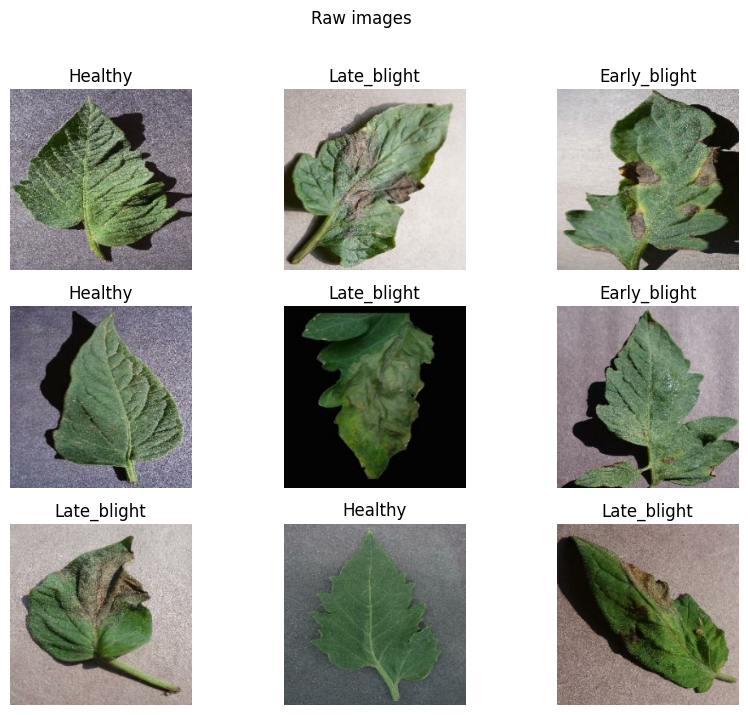

In [ ]:
#do  not run this cell else wahala
for images, labels in train_ds.take(1):
  print(f'Image shape:', images.shape)
  plt.figure(figsize=(10,8))
  for i in range(9):
    ax = plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype('uint8'))
    plt.title(CLASS_NAMES[int(labels[i])])
    plt.axis('off')
  plt.suptitle('Raw images')
  plt.show()

## Define Data Augmentation Layers
This section defines a `tf.keras.Sequential` model for data augmentation, including random flips, rotations, zooms, translations, contrast, and brightness adjustments.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2)
])

## Optimize Dataset Performance
These lines optimize the dataset loading pipeline using caching (`.cache()`), shuffling (`.shuffle()`), and prefetching (`.prefetch(tf.data.AUTOTUNE)`) for improved training efficiency.

In [ ]:
train_ds = train_ds.cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)

## Build Base Model (EfficientNetB0)
This section loads the `EfficientNetB0` pre-trained model from Keras applications, excluding the top classification layer. The base model is initially set to be non-trainable.

In [ ]:
base_model = EfficientNetB0(include_top=False, weights='imagenet',
                            input_shape=(img_height, img_width, 3))

base_model.trainable = False
print(f'Base model layers: {len(base_model.layers)}')
print(f'Trainable parameters: {len(base_model.trainable_variables)}')

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model layers: 238
Trainable parameters: 0


## Define Model Architecture (Phase 1: Head Training)
This cell constructs the full model by stacking the data augmentation layers, an EfficientNet preprocessing layer, the pre-trained EfficientNetB0 base model, global average pooling, batch normalization, dropout, and dense classification layers.

In [ ]:
@tf.keras.utils.register_keras_serializable()
class EfficientNetPreprocessing(tf.keras.layers.Layer):
  def call(self, x):
    return tf.keras.applications.efficientnet.preprocess_input(x)

model = tf.keras.Sequential([
    tf.keras.Input(shape=(img_height, img_width, 3)),
    data_augmentation,
    EfficientNetPreprocessing(),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficient_net_preprocessing     │ (None, 224, 224, 3)    │             0 │
│ (EfficientNetPreprocessing)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,219,046 (16.09 MB)

 Trainable params: 166,915 (652.01 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

## Data Augmentation Summary
Displays a summary of the data augmentation layers, showing the output shape and number of parameters for each layer.

In [ ]:
data_augmentation.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 224, 224, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ (None, 224, 224, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Define Callbacks for Phase 1 Training
This section defines `ModelCheckpoint`, `EarlyStopping`, and `ReduceLROnPlateau` callbacks to monitor training progress, save the best model, prevent overfitting, and adjust the learning rate.

In [ ]:
phase_1 = '/content/drive/MyDrive/CapStone_Tomatao/models/detect_phase1.keras'

checkpoint_1 = ModelCheckpoint(
    filepath=phase_1,
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1
)

## Compile Model for Phase 1 Training
The model is compiled with the Adam optimizer (low learning rate), sparse categorical crossentropy loss, and accuracy as the metric. This phase typically trains only the newly added classification head.

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Train Model (Phase 1: Head Training)
This cell initiates the training process for the first phase, using the `train_ds` and `val_ds` datasets and the defined callbacks.

In [ ]:
print('Training')

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[checkpoint_1, early_stopping, reduce_lr]
)

print()
print('Training finished')

Training
Epoch 1/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.6139 - loss: 0.9242
Epoch 1: val_loss improved from None to 0.61938, saving model to /content/drive/MyDrive/CapStone_Tomatao/models/detect_phase1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CapStone_Tomatao/models/detect_phase1.keras
99/99 ━━━━━━━━━━━━━━━━━━━━ 339s 821ms/step - accuracy: 0.7088 - loss: 0.7180 - val_accuracy: 0.7849 - val_loss: 0.6194 - learning_rate: 1.0000e-04
Epoch 2/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8358 - loss: 0.4174
Epoch 2: val_loss improved from 0.61938 to 0.42159, saving model to /content/drive/MyDrive/CapStone_Tomatao/models/detect_phase1.keras

Epoch 2: finished saving model to /content/drive/MyDrive/CapStone_Tomatao/models/detect_phase1.keras
99/99 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 0.8403 - loss: 0.4048 - val_accuracy: 0.8650 - val_loss: 0.4216 - learning_rate: 1.0000e-04
Epoch 3/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accu

## Inspect Validation Loss from Phase 1
This displays the validation loss values recorded during the first phase of training, which can be useful for analysis.

In [ ]:
history1.history['val_loss']

[0.6193805932998657,
 0.4215920865535736,
 0.3101801872253418,
 0.2697210907936096,
 0.2496238499879837,
 0.22046926617622375,
 0.20926478505134583,
 0.19192303717136383,
 0.18518012762069702,
 0.17045016586780548,
 0.17241790890693665,
 0.17087125778198242,
 0.1722852736711502,
 0.16949371993541718,
 0.17022822797298431,
 0.1676420271396637,
 0.166575625538826,
 0.1669093668460846,
 0.16434015333652496,
 0.15788091719150543,
 0.15513674914836884,
 0.15468241274356842,
 0.15340355038642883,
 0.15172602236270905,
 0.15331275761127472,
 0.15391458570957184,
 0.14818863570690155,
 0.14994437992572784,
 0.1471198946237564,
 0.1488187462091446]

## Plot Training History Function
This function defines how to plot the training and validation accuracy and loss over epochs, creating two subplots for clear visualization.

In [ ]:
def plot_history(history, title):
  acc = history.history['accuracy']
  val_acc = history.history['val_accuracy']
  loss = history.history['loss']
  val_loss = history.history['val_loss']
  epochs = range(1, len(acc)+1)

  plt.figure(figsize=(14,5))

  plt.subplot(1,2,1)
  plt.plot(epochs, acc, 'g-o', label='Training accuracy')
  plt.plot(epochs, val_acc, 'b-o', label='Validation accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()

  plt.subplot(1,2,2)
  plt.plot(epochs, loss, 'g-o', label='Training loss')
  plt.plot(epochs, val_loss, 'b-o', label='Validation loss')
  plt.title('loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()

  plt.suptitle(title)
  plt.tight_layout()
  plt.show()

## Plot Training History (Phase 1)
Calls the `plot_history` function to visualize the training and validation metrics for the first phase of training (head training).

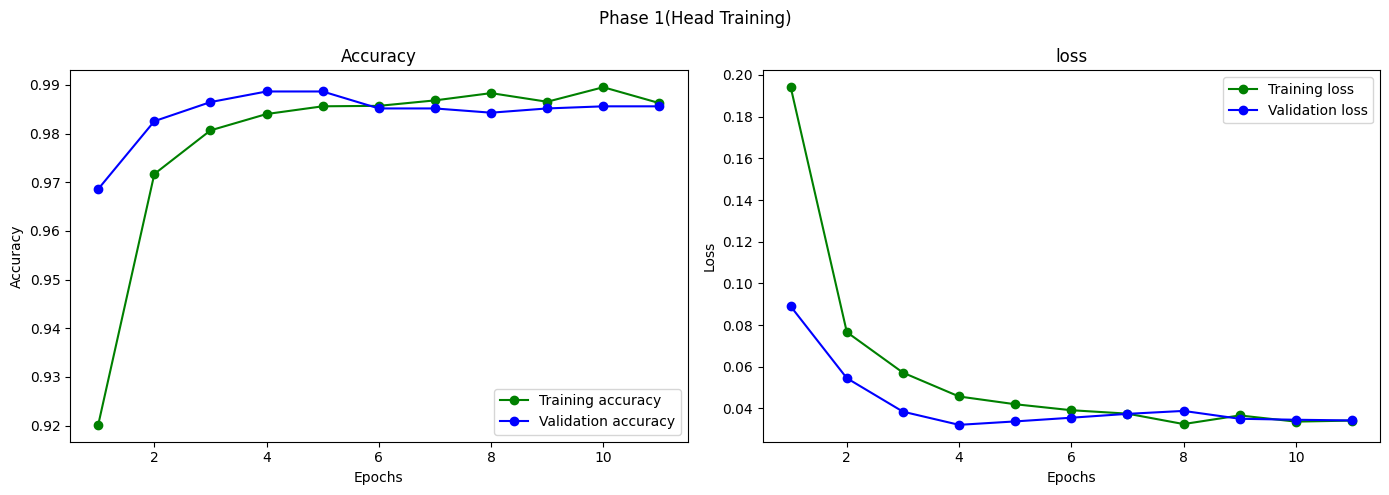

In [ ]:
plot_history(history1, 'Phase 1(Head Training)')

## Save Training History (Phase 1)
This cell saves the training history (accuracy, validation accuracy, loss, validation loss) from the first phase into a JSON file in Google Drive.

In [ ]:
import json

history_data_1 = {
    'accuracy': history1.history['accuracy'],
    'val_accuracy': history1.history['val_accuracy'],
    'loss': history1.history['loss'],
    'val_loss': history1.history['val_loss']
}

with open('/content/drive/MyDrive/CapStone_Tomatao/models/history1.json', 'w') as f:
    json.dump(history_data_1, f)

print('History saved')

History saved


## Load Training History (Phase 1)
This cell attempts to load the saved training history from Phase 1. There is a typo in the path (`/cont/history1.json`), it should likely be `/content/drive/MyDrive/CapStone_Tomatao/models/history1.json`.

In [ ]:
with open('/cont/history1.json', 'r') as f:
    history_data = json.load(f)

## Fine-tuning Setup (Phase 2)
This section loads the best model from Phase 1, unfreezes a portion of the base model's layers for fine-tuning, and prints information about trainable and frozen layers. Batch normalization layers are kept frozen.

In [ ]:
model = tf.keras.models.load_model(phase_1)
model.get_layer(base_model.name).trainable = True

for layer in model.get_layer(base_model.name).layers[:-30]:
  layer.trainable = False

print(f'Total Trainable parameters: {len(model.trainable_variables)}')

base = model.get_layer(base_model.name)
trainables = [l.name for l in base.layers if l.trainable]
non_trainables = [l.name for l in base.layers if not l.trainable]

print(f'Frozen layers:   {len(non_trainables)}')
print(f'Trainable layers: {len(trainables)}')
print(f'Trainable layer names: {trainables}')

for layer in model.get_layer(base_model.name).layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

Total Trainable parameters: 34
Frozen layers:   208
Trainable layers: 30
Trainable layer names: ['block6d_expand_bn', 'block6d_expand_activation', 'block6d_dwconv', 'block6d_bn', 'block6d_activation', 'block6d_se_squeeze', 'block6d_se_reshape', 'block6d_se_reduce', 'block6d_se_expand', 'block6d_se_excite', 'block6d_project_conv', 'block6d_project_bn', 'block6d_drop', 'block6d_add', 'block7a_expand_conv', 'block7a_expand_bn', 'block7a_expand_activation', 'block7a_dwconv', 'block7a_bn', 'block7a_activation', 'block7a_se_squeeze', 'block7a_se_reshape', 'block7a_se_reduce', 'block7a_se_expand', 'block7a_se_excite', 'block7a_project_conv', 'block7a_project_bn', 'top_conv', 'top_bn', 'top_activation']


## Compile Model for Phase 2 Training (Fine-tuning)
The model is recompiled with a very low learning rate for fine-tuning the unfrozen layers of the base model along with the classification head.

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Define Checkpoint for Phase 2 Training
This cell defines a `ModelCheckpoint` callback specifically for saving the best model during the second phase of training.

In [ ]:
phase_2 = '/content/drive/MyDrive/CapStone_Tomatao/models/detect_phase2.keras'

checkpoint_2 = ModelCheckpoint(
    filepath=phase_2,
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

## Train Model (Phase 2: Fine-tuning)
This cell continues the training process for the second phase (fine-tuning), using the same datasets and callbacks, but with the modified model (partially unfrozen base model).

In [ ]:
print('Training')

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[checkpoint_2, early_stopping, reduce_lr]
)

print()
print('Training finished')

Training
Epoch 1/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9517 - loss: 0.1318
Epoch 1: val_loss improved from None to 0.14135, saving model to /content/drive/MyDrive/CapStone_Tomatao/models/detect_phase2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CapStone_Tomatao/models/detect_phase2.keras
99/99 ━━━━━━━━━━━━━━━━━━━━ 28s 153ms/step - accuracy: 0.9549 - loss: 0.1316 - val_accuracy: 0.9451 - val_loss: 0.1414 - learning_rate: 1.0000e-05
Epoch 2/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9452 - loss: 0.1360
Epoch 2: val_loss improved from 0.14135 to 0.13900, saving model to /content/drive/MyDrive/CapStone_Tomatao/models/detect_phase2.keras

Epoch 2: finished saving model to /content/drive/MyDrive/CapStone_Tomatao/models/detect_phase2.keras
99/99 ━━━━━━━━━━━━━━━━━━━━ 12s 120ms/step - accuracy: 0.9514 - loss: 0.1281 - val_accuracy: 0.9451 - val_loss: 0.1390 - learning_rate: 1.0000e-05
Epoch 3/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accur

## Inspect Validation Loss from Phase 2
This displays the validation loss values recorded during the second phase of training (fine-tuning).

In [ ]:
history2.history['val_loss']

[0.14135032892227173,
 0.13900339603424072,
 0.13395552337169647,
 0.1357710361480713,
 0.1207505539059639,
 0.11104561388492584,
 0.11125344038009644,
 0.10562919080257416,
 0.10696997493505478,
 0.10648075491189957,
 0.10148143768310547,
 0.10081052035093307,
 0.09299175441265106,
 0.09550107270479202,
 0.09260500967502594,
 0.08818201720714569,
 0.08766432106494904,
 0.08403829485177994,
 0.08158272504806519,
 0.07624749839305878,
 0.0802457332611084,
 0.08228141069412231,
 0.08047274500131607,
 0.08002834022045135,
 0.07833833992481232,
 0.07820906490087509,
 0.07770935446023941]

## Plot Training History (Phase 2)
Calls the `plot_history` function to visualize the training and validation metrics for the second phase of training (fine-tuning).

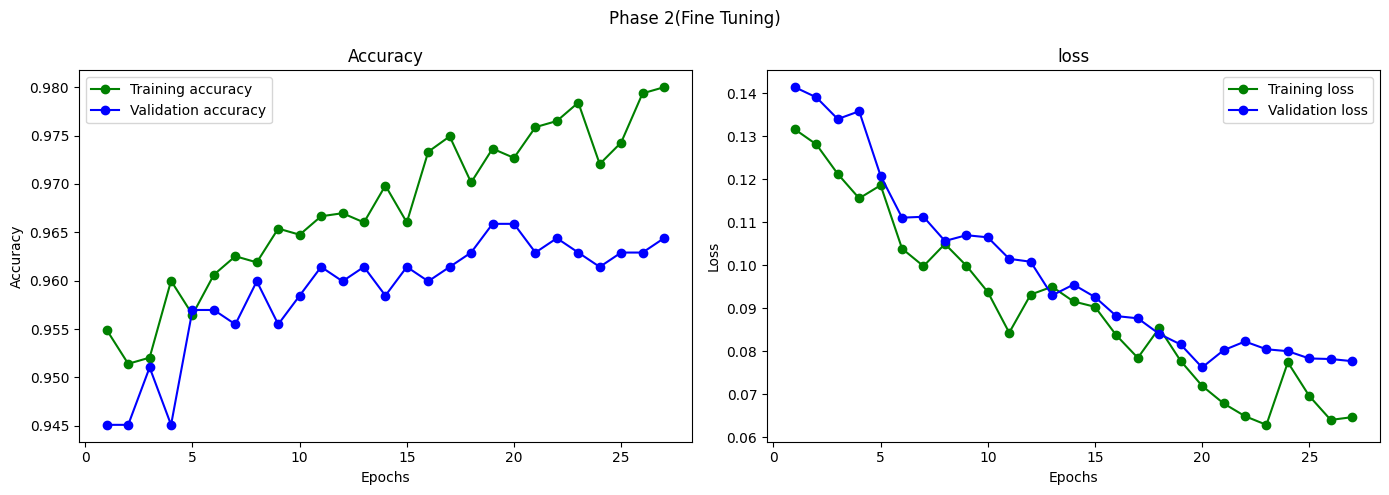

In [ ]:
plot_history(history2, 'Phase 2(Fine Tuning)')

## Save Training History (Phase 2)
This cell saves the training history from the second phase into a JSON file in Google Drive.

In [ ]:
history_data_2 = {
    'accuracy': history2.history['accuracy'],
    'val_accuracy': history2.history['val_accuracy'],
    'loss': history2.history['loss'],
    'val_loss': history2.history['val_loss']
}

with open('/content/drive/MyDrive/CapStone_Tomatao/models/history2.json', 'w') as f:
    json.dump(history_data_2, f)

print('History saved')

History saved


## Load Training History (Phase 2)
This cell attempts to load the saved training history from Phase 2. There is a typo in the path (`/content/drive/Capstone_Project/Cocoa_detection/Models/history2.json`), it should likely be `/content/drive/MyDrive/CapStone_Tomatao/models/history2.json`.

In [ ]:
with open('/content/drive/MyDrive/Capstone_Project/Cocoa_detection/Models/history2.json', 'r') as f:
    history_data = json.load(f)

## Evaluate Best Model on Test Set
This section loads the best model from Phase 2 (fine-tuning) and evaluates its performance on the unseen test dataset, printing the test accuracy and loss.

In [ ]:
@tf.keras.utils.register_keras_serializable()
class EfficientNetPreprocessing(tf.keras.layers.Layer):
  def call(self, x):
    return tf.keras.applications.efficientnet.preprocess_input(x)

phase_2 = '/content/drive/MyDrive/CapStone_Tomatao/models/detect_phase2.keras'

best_model = tf.keras.models.load_model(phase_2)

test_loss, test_acc = best_model.evaluate(test_ds)
print(f'Test accuracy: {test_acc*100:.2f}%')
print(f'Test loss: {test_loss:.4f}')

22/22 ━━━━━━━━━━━━━━━━━━━━ 75s 3s/step - accuracy: 0.9616 - loss: 0.1212
Test accuracy: 96.16%
Test loss: 0.1212


## Generate Predictions and Classification Report
This cell generates predictions on the test dataset and then prints a detailed classification report, including precision, recall, f1-score, and support for each class.

In [ ]:
y_pred = []
y_true = []

for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    y_pred.extend(tf.argmax(preds, axis=1).numpy().flatten())
    y_true.extend(labels.numpy().flatten())

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

              precision    recall  f1-score   support

Early_blight       0.98      0.89      0.93       150
     Healthy       0.95      1.00      0.98       240
 Late_blight       0.96      0.97      0.97       287

    accuracy                           0.96       677
   macro avg       0.96      0.95      0.96       677
weighted avg       0.96      0.96      0.96       677



## Plot Confusion Matrix
This cell computes and visualizes the confusion matrix for the model's predictions on the test set, providing a clear view of true positives, false positives, and false negatives for each class.

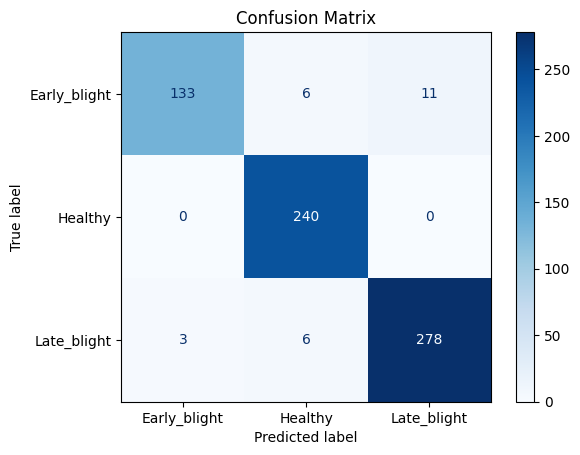

In [ ]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()